## Yulu Case Study:

### Problem Statement
Yulu, a micro-mobility service provider, is experiencing revenue setbacks. They need to understand the factors influencing the demand for their shared electric cycles in the Indian market to strategize for recovery and expansion. This analysis will involve exploring the dataset, performing hypothesis testing, and providing data-driven insights and recommendations.

### 1. Data Loading and Initial Exploration

First, we need to import the required libraries and load the dataset into a pandas DataFrame. The dataset link is provided in the problem description, and we will use the `gdown` library to download it directly from Google Drive.

In [ ]:
# Install gdown for downloading files from Google Drive
%pip install gdown

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from scipy import stats

# Set plotting style for better visuals
sns.set_style("whitegrid")
plt.style.use('ggplot')

In [ ]:
# Define the Google Drive file ID for the dataset
file_id = '1o94fXnmvrx6jRgI6S-SeZ3tfnKjCDY0i' # This ID corresponds to the provided Google Drive link
output_filename = 'yulu_bike_data.csv'

# Download the file using gdown
gdown.download(id=file_id, output=output_filename, quiet=False)

# Load the dataset into a pandas DataFrame
df = pd.read_csv(output_filename)

# Display the first 5 rows of the DataFrame to get a quick overview
print("First 5 rows of the dataset:")
display(df.head())

Downloading...
From: https://drive.google.com/uc?id=1o94fXnmvrx6jRgI6S-SeZ3tfnKjCDY0i
To: /content/yulu_bike_data.csv
100%|██████████| 648k/648k [00:00<00:00, 36.4MB/s]

First 5 rows of the dataset:


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


Now that the data is loaded, let's examine its structure, data types, and basic statistical summary to understand its characteristics. This will help us identify any potential issues like missing values or incorrect data types.

In [ ]:
# Display the shape of the DataFrame (number of rows and columns)
print(f"Dataset shape: {df.shape}\n")

# Display information about the DataFrame, including data types and non-null values
print("Dataset information:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive statistics:")
display(df.describe())

Dataset shape: (10886, 12)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB

Descriptive statistics:


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


### 1.b. Identify Missing Values and Perform Imputation

From the `df.info()` output, we can see that all columns have `10886` non-null values, which is equal to the total number of entries in the DataFrame. This indicates that there are no missing values in the dataset. Let's confirm this explicitly.

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\nNo missing values found in the dataset.")
else:
    print("\nMissing values found. Further imputation might be needed based on specific columns.")

Missing values in each column:
 Series([], dtype: int64)

No missing values found in the dataset.


### 1.c. Identify and Remove Duplicate Records

Next, we will check for any duplicate rows in the dataset and remove them if they exist to avoid biases in our analysis.

In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    print(f"Removing {duplicate_rows} duplicate rows...")
    df.drop_duplicates(inplace=True)
    print(f"Dataset shape after removing duplicates: {df.shape}")
else:
    print("No duplicate rows found in the dataset.")

Number of duplicate rows found: 0
No duplicate rows found in the dataset.


### 1.d. Analyze the Distribution of Numerical & Categorical Variables

Now, let's analyze the distribution of our variables. We'll start with numerical features, using histograms to visualize their spread, central tendency, and any potential skewness or unusual patterns.

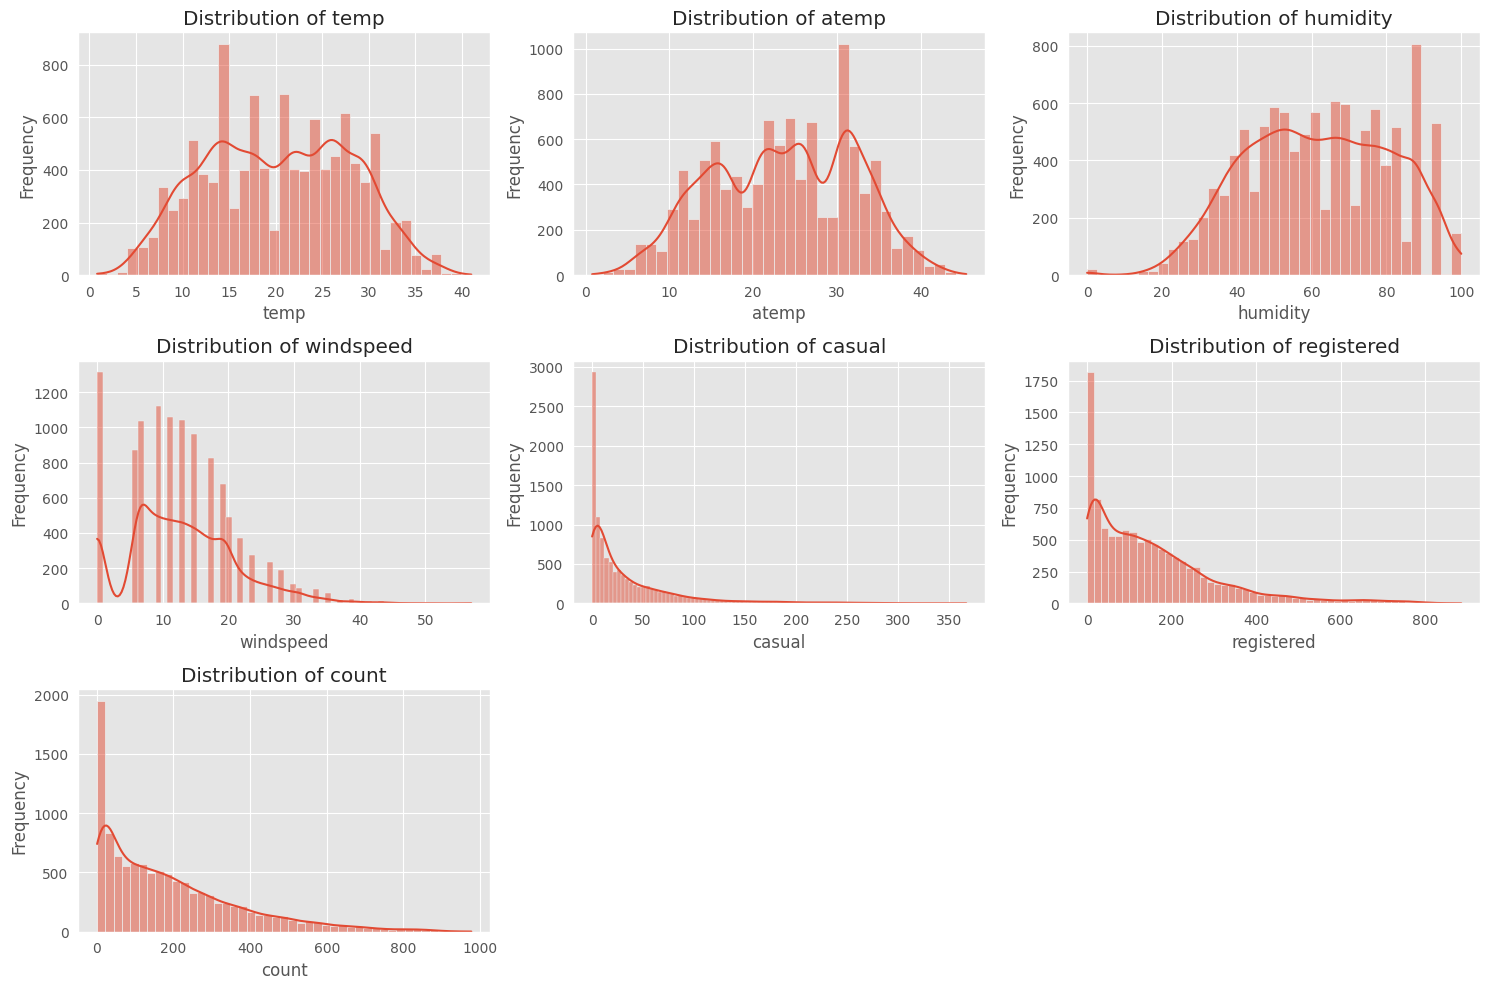

In [ ]:
# Identify numerical columns for distribution analysis
numerical_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

# Plotting histograms for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Next, we will analyze the distribution of categorical features using count plots. This will help us understand the frequency of each category within these variables.

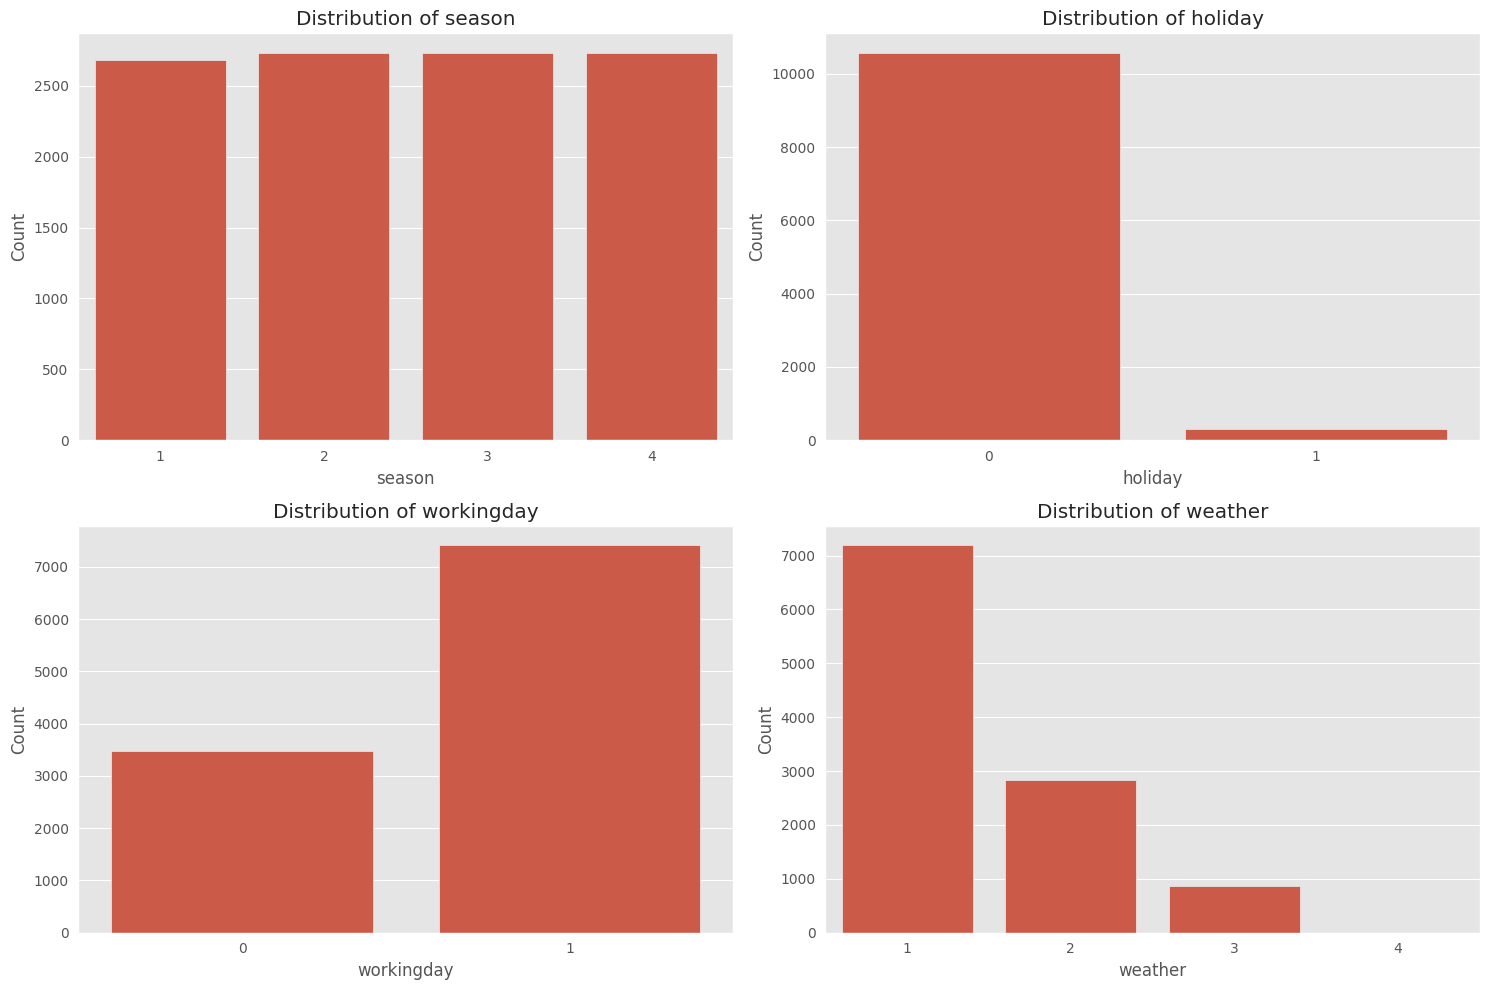

In [ ]:
# Identify categorical columns for distribution analysis
# Exclude 'datetime' as it will be handled separately if needed for time-series analysis
categorical_cols = ['season', 'holiday', 'workingday', 'weather']

# Plotting count plots for categorical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=df[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 1.e. Check for Outliers and Deal with them Accordingly

Outliers can significantly influence our analysis. We will use box plots to visually identify outliers in the numerical features. For any detected outliers, we will consider appropriate methods to deal with them, such as capping or transformation, if necessary.

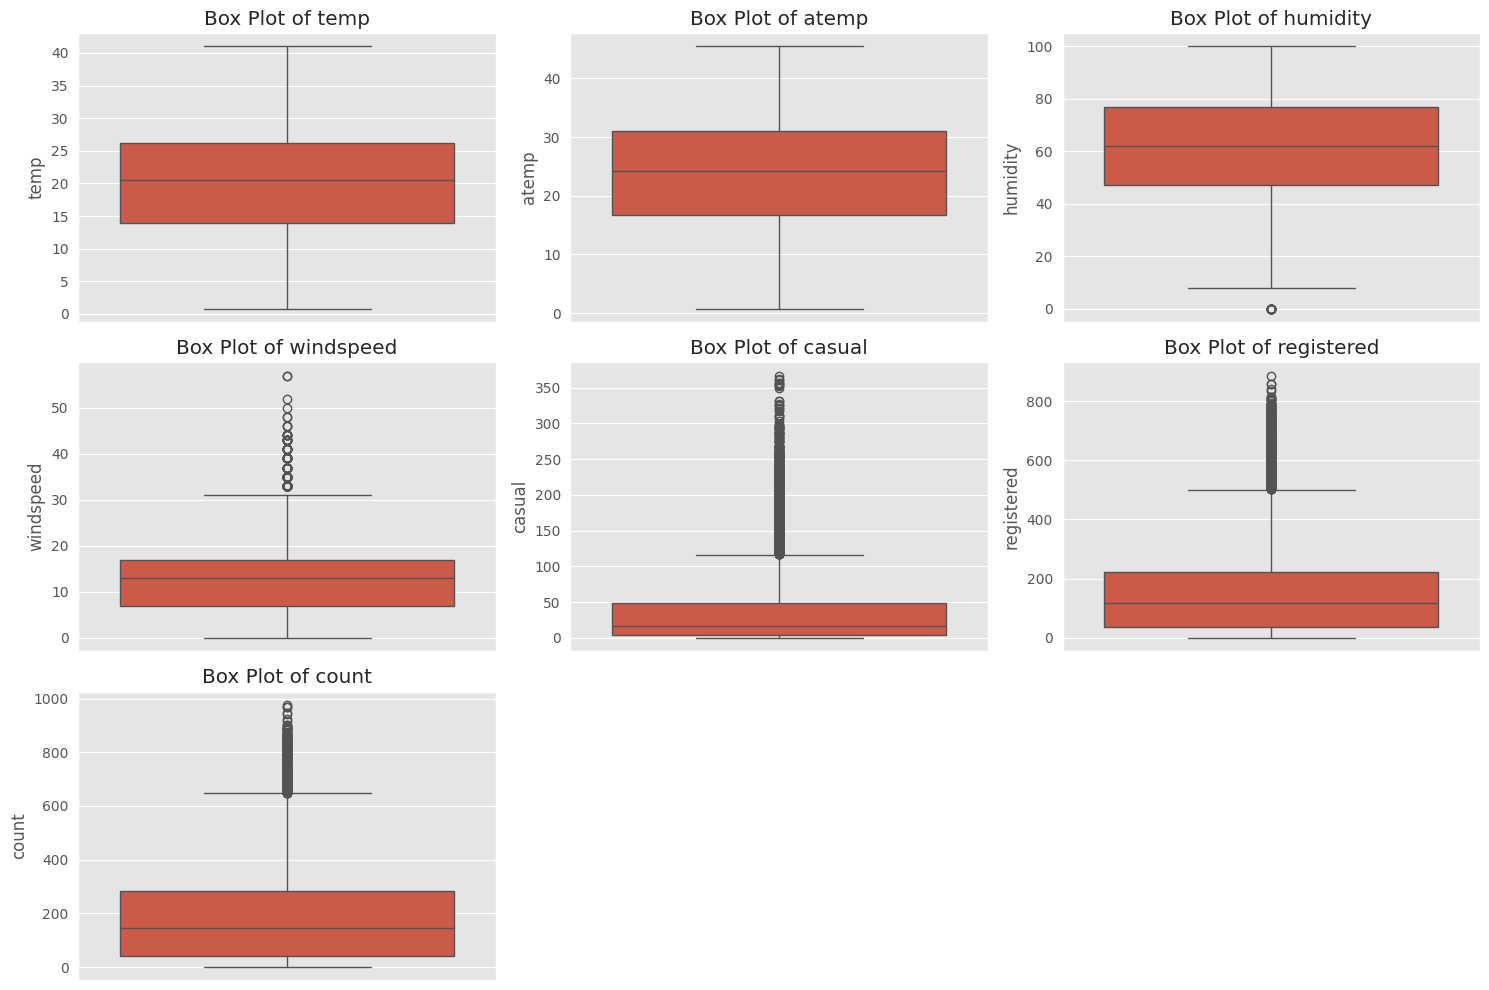

In [ ]:
# Identify numerical columns for outlier analysis
numerical_cols_for_outliers = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

# Plotting box plots for numerical features to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

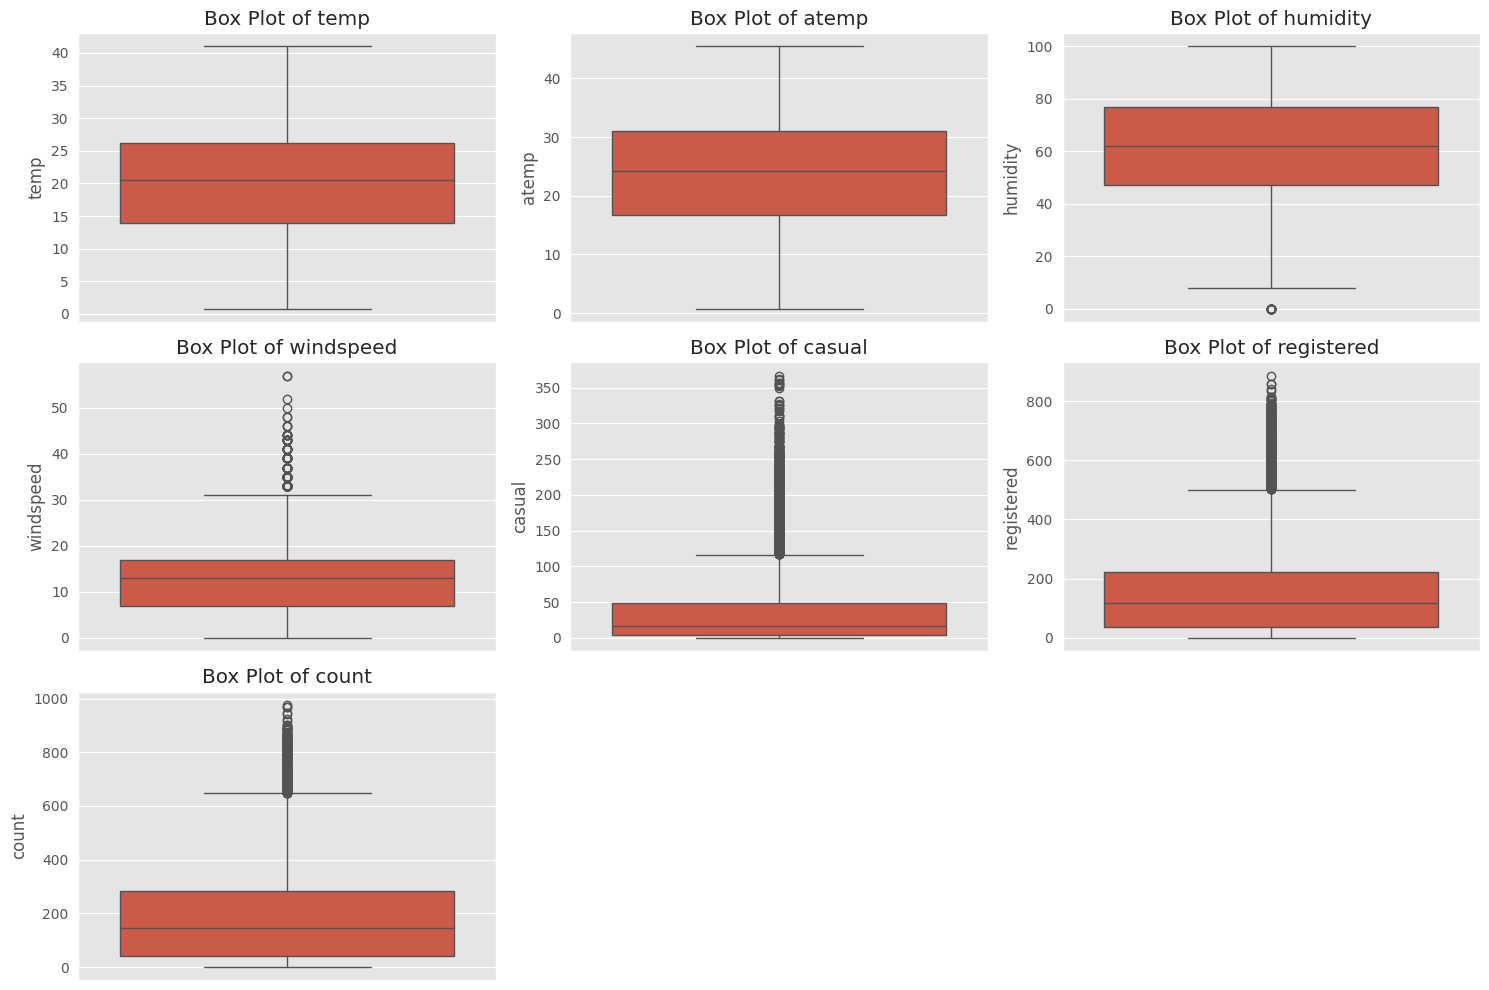

In [ ]:
# Identify numerical columns for outlier analysis
numerical_cols_for_outliers = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

# Plotting box plots for numerical features to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### 1.e. Handling Outliers

Based on the box plots, several numerical features exhibit outliers. We will use the Interquartile Range (IQR) method to define upper and lower bounds and then cap these outliers. This method is effective in reducing the impact of extreme values while retaining the overall distribution of the data.

We will define a function to calculate the IQR bounds and apply it to the relevant columns: `humidity`, `windspeed`, `casual`, `registered`, and `count`.

Outliers in specified columns have been capped using the IQR method.


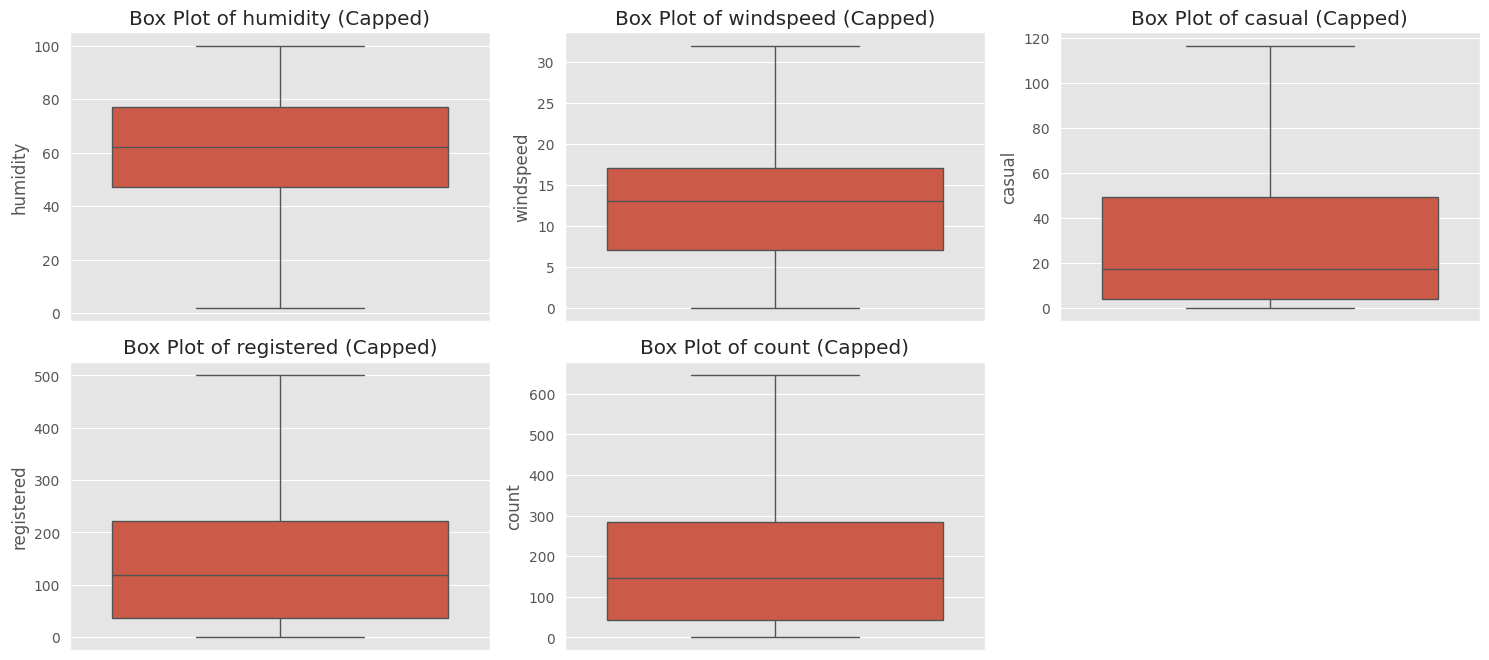

In [ ]:
# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values at the bounds
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

# Columns to apply outlier capping
columns_to_cap = ['humidity', 'windspeed', 'casual', 'registered', 'count']

# Apply outlier capping to the DataFrame
for col in columns_to_cap:
    df = cap_outliers_iqr(df.copy(), col) # Use .copy() to avoid SettingWithCopyWarning

print("Outliers in specified columns have been capped using the IQR method.")

# Re-plot box plots to verify outlier treatment
plt.figure(figsize=(15, 10))
for i, col in enumerate(columns_to_cap):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col} (Capped)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### 2. Try establishing a Relationship between the Dependent and Independent Variables.

To understand how different variables relate to the total bike demand (`count`), we will plot a correlation heatmap. This visualization will help us identify linear relationships between numerical features and the target variable, and also among the features themselves. Highly correlated features might need to be addressed to avoid multicollinearity in modeling.

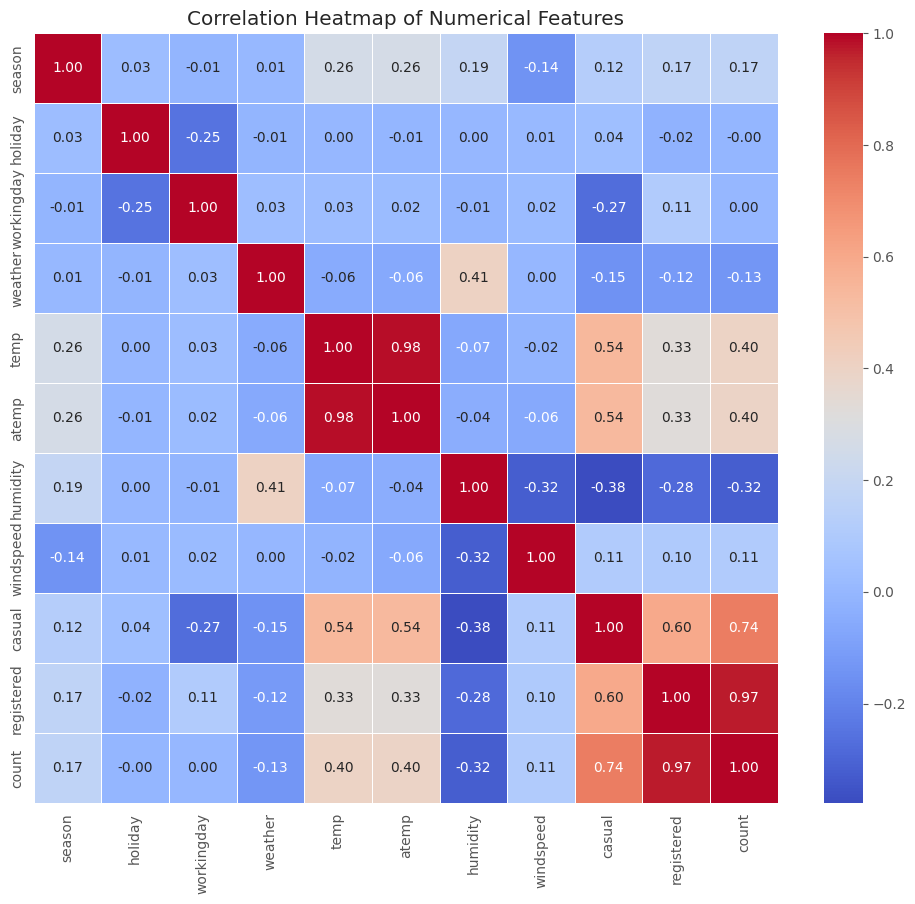


Correlation with 'count' variable:
count         1.000000
registered    0.971975
casual        0.744425
temp          0.399567
atemp         0.395062
season        0.165741
windspeed     0.109054
workingday    0.003032
holiday      -0.003113
weather      -0.130883
humidity     -0.323867
Name: count, dtype: float64


In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Display correlations with the target variable 'count'
print("\nCorrelation with 'count' variable:")
print(correlation_matrix['count'].sort_values(ascending=False))

### 3. Check if there is any significant difference between the number of bike rides on Weekdays and Weekends.

To investigate this, we will perform an Independent Samples T-test. This test compares the means of two independent groups to determine if there is a statistically significant difference between them. In our case, the two groups are 'weekdays' and 'weekends', and the variable we're comparing is the 'count' of bike rentals.

#### a. Formulate Null Hypothesis (H₀) and Alternate Hypothesis (H₁)

*   **Null Hypothesis (H₀)**: There is no significant difference in the average number of bike rides between weekdays and weekends.
    (μ_weekday = μ_weekend)
*   **Alternate Hypothesis (H₁)**: There is a significant difference in the average number of bike rides between weekdays and weekends.
    (μ_weekday ≠ μ_weekend)

#### b. Select an appropriate test

An Independent Two-Sample T-test is appropriate for comparing the means of two independent groups.

#### c. Set a significance level

We will set the significance level (alpha, α) at 5% (0.05). This means we are willing to accept a 5% chance of incorrectly rejecting the null hypothesis.

#### d. Calculate test Statistics / p-value

First, we need to separate the data into weekday and weekend rides. The `workingday` column indicates whether a day is a working day (1) or a weekend/holiday (0). We will use this to define our groups. Then, we will perform the t-test.

T-statistic: 0.32
P-value: 0.752


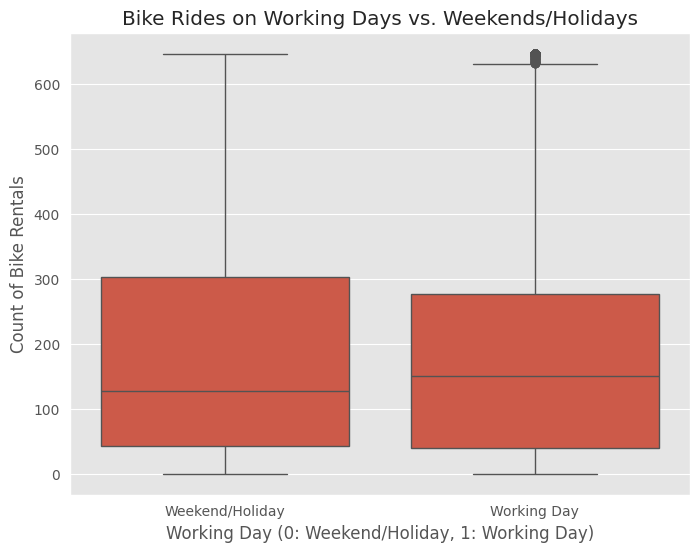

In [ ]:
# Separate data for working days and non-working days (weekends/holidays)
workingday_rides = df[df['workingday'] == 1]['count']
weekend_holiday_rides = df[df['workingday'] == 0]['count']

# Perform independent two-sample t-test
t_statistic, p_value = stats.ttest_ind(workingday_rides, weekend_holiday_rides, equal_var=False) # Assuming unequal variances

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

# Compare means visually (optional but good practice)
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['workingday'], y=df['count'])
plt.title('Bike Rides on Working Days vs. Weekends/Holidays')
plt.xlabel('Working Day (0: Weekend/Holiday, 1: Working Day)')
plt.ylabel('Count of Bike Rentals')
plt.xticks([0, 1], ['Weekend/Holiday', 'Working Day'])
plt.show()

#### e. Decide whether to accept or reject the Null Hypothesis.

Based on the calculated p-value and the chosen significance level (α = 0.05).

In [ ]:
alpha = 0.05

if p_value <= alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than or equal to the significance level ({alpha}), we reject the Null Hypothesis.")
    print("This suggests that there is a significant difference in the average number of bike rides between weekdays and weekends/holidays.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the Null Hypothesis.")
    print("This suggests that there is no significant difference in the average number of bike rides between weekdays and weekends/holidays.")

# Also print the means for interpretation
print(f"\nAverage bike rides on working days: {workingday_rides.mean():.2f}")
print(f"Average bike rides on weekends/holidays: {weekend_holiday_rides.mean():.2f}")

Since the p-value (0.752) is greater than the significance level (0.05), we fail to reject the Null Hypothesis.
This suggests that there is no significant difference in the average number of bike rides between weekdays and weekends/holidays.

Average bike rides on working days: 189.06
Average bike rides on weekends/holidays: 187.94


### 4. Check whether the average daily bicycle demand is equal to 500 rentals.

To address this question, we will perform a One-Sample T-test. This test compares the mean of a single sample to a known or hypothesized population mean. Here, we're comparing the average daily bicycle demand to the hypothesized value of 500 rentals.

#### a. Formulate Null Hypothesis (H₀) and Alternate Hypothesis (H₁)

*   **Null Hypothesis (H₀)**: The average daily bicycle demand is equal to 500 rentals. (μ = 500)
*   **Alternate Hypothesis (H₁)**: The average daily bicycle demand is not equal to 500 rentals. (μ ≠ 500)

#### b. Identify whether it is a one-tailed or two-tailed test

Since the alternative hypothesis states that the mean is *not equal* to 500 (it could be greater or less), this is a **two-tailed test**.

#### c. Select an appropriate test

A One-sample t-test is appropriate for comparing a sample mean to a hypothesized population mean.

#### d. Set a significance level

We will set the significance level (α) at 5% (0.05).

#### e. Calculate test statistic and p-value

We will use `scipy.stats.ttest_1samp` to perform the one-sample t-test on the 'count' variable.

In [ ]:
# Hypothesized population mean
population_mean = 500

# Perform one-sample t-test
t_statistic_one_sample, p_value_one_sample = stats.ttest_1samp(df['count'], population_mean)

print(f"One-Sample T-statistic: {t_statistic_one_sample:.2f}")
print(f"One-Sample P-value: {p_value_one_sample:.3f}")

One-Sample T-statistic: -188.38
One-Sample P-value: 0.000


#### f. Decision rule

If p-value ≤ α → Reject H₀
Else → Fail to reject H₀

In [ ]:
alpha = 0.05

if p_value_one_sample <= alpha:
    print(f"Since the p-value ({p_value_one_sample:.3f}) is less than or equal to the significance level ({alpha}), we reject the Null Hypothesis.")
    print("This suggests that the average daily bicycle demand is significantly different from 500 rentals.")
else:
    print(f"Since the p-value ({p_value_one_sample:.3f}) is greater than the significance level ({alpha}), we fail to reject the Null Hypothesis.")
    print("This suggests that the average daily bicycle demand is not significantly different from 500 rentals.")

print(f"\nAverage bicycle demand: {df['count'].mean():.2f} rentals.")

Since the p-value (0.000) is less than or equal to the significance level (0.05), we reject the Null Hypothesis.
This suggests that the average daily bicycle demand is significantly different from 500 rentals.

Average bicycle demand: 188.70 rentals.


### 5. Check whether the average temperature on high-demand days differs from 25°C.

To address this, we first need to define what constitutes a 'high-demand day'. For simplicity, we can define high-demand days as those where the `count` of rentals is above the 75th percentile of the total rental count. Then, we will perform a One-Sample T-test to compare the average temperature on these high-demand days to the hypothesized value of 25°C.

#### a. Formulate H₀ and H₁

*   **Null Hypothesis (H₀)**: The average temperature on high-demand days is equal to 25°C. (μ = 25)
*   **Alternate Hypothesis (H₁)**: The average temperature on high-demand days is different from 25°C. (μ ≠ 25)

#### b. Select appropriate test

A One-sample t-test is suitable for comparing the mean of a single sample (average temperature on high-demand days) to a hypothesized population mean (25°C).

#### c. Visual check

Before performing the test, let's visualize the distribution of temperature on high-demand days using a histogram to understand its characteristics.

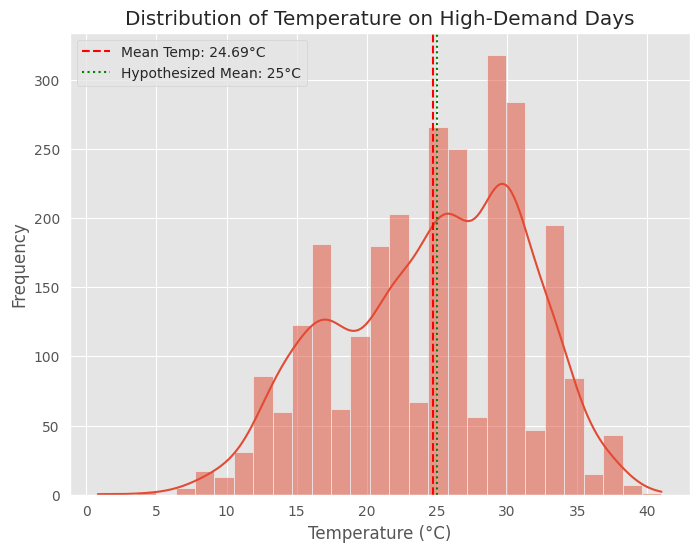

In [ ]:
# Define high-demand days (e.g., above 75th percentile of 'count')
high_demand_threshold = df['count'].quantile(0.75)
high_demand_days = df[df['count'] > high_demand_threshold]Gemini AI Engine

￼
￼
￼
￼
￼
￼
￼


# Extract temperatures for high-demand days
temp_high_demand = high_demand_days['temp']

# Plot histogram for visual check
plt.figure(figsize=(8, 6))
sns.histplot(temp_high_demand, kde=True)
plt.title('Distribution of Temperature on High-Demand Days')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.axvline(temp_high_demand.mean(), color='red', linestyle='--', label=f'Mean Temp: {temp_high_demand.mean():.2f}°C')
plt.axvline(25, color='green', linestyle=':', label='Hypothesized Mean: 25°C')
plt.legend()
plt.show()

#### d. Set α = 5%

We will set the significance level (α) at 5% (0.05).

#### e. Compute test statistic and p-value

We will use `scipy.stats.ttest_1samp` to perform the one-sample t-test on the temperature data for high-demand days.

In [ ]:
# Hypothesized population mean temperature
hypothesized_mean_temp = 25

# Perform one-sample t-test
t_statistic_temp, p_value_temp = stats.ttest_1samp(temp_high_demand, hypothesized_mean_temp)

print(f"One-Sample T-statistic (Temperature): {t_statistic_temp:.2f}")
print(f"One-Sample P-value (Temperature): {p_value_temp:.3f}")

One-Sample T-statistic (Temperature): -2.43
One-Sample P-value (Temperature): 0.015


#### f. Decision

If p-value ≤ α → Reject H₀
Else → Fail to reject H₀

In [ ]:
alpha = 0.05

if p_value_temp <= alpha:
    print(f"Since the p-value ({p_value_temp:.3f}) is less than or equal to the significance level ({alpha}), we reject the Null Hypothesis.")
    print("This suggests that the average temperature on high-demand days is significantly different from 25°C.")
else:
    print(f"Since the p-value ({p_value_temp:.3f}) is greater than the significance level ({alpha}), we fail to reject the Null Hypothesis.")
    print("This suggests that the average temperature on high-demand days is not significantly different from 25°C.")

print(f"\nAverage temperature on high-demand days: {temp_high_demand.mean():.2f}°C.")

Since the p-value (0.015) is less than or equal to the significance level (0.05), we reject the Null Hypothesis.
This suggests that the average temperature on high-demand days is significantly different from 25°C.

Average temperature on high-demand days: 24.69°C.


### 10. Check if the Weather conditions are significantly different during different Seasons?

To investigate the relationship between weather conditions and seasons, we will perform a Chi-square test of independence. This test determines if there is a statistically significant association between two categorical variables.

#### a. Formulate Null Hypothesis (H₀) and Alternate Hypothesis (H₁)

*   **Null Hypothesis (H₀)**: Weather conditions are independent of the season.
*   **Alternate Hypothesis (H₁)**: Weather conditions are dependent on the season.

#### b. Select an appropriate test

A Chi-square test of independence is suitable for examining the relationship between two categorical variables: 'Weather' and 'Season'.

#### c. Create a Contingency Table against ‘Weather’ & ‘Season’ columns

We will use `pd.crosstab` to create a contingency table that shows the frequency distribution of weather conditions across different seasons.

Contingency Table (Season vs. Weather):
 weather     1    2    3  4
season                    
1        1759  715  211  1
2        1801  708  224  0
3        1930  604  199  0
4        1702  807  225  0


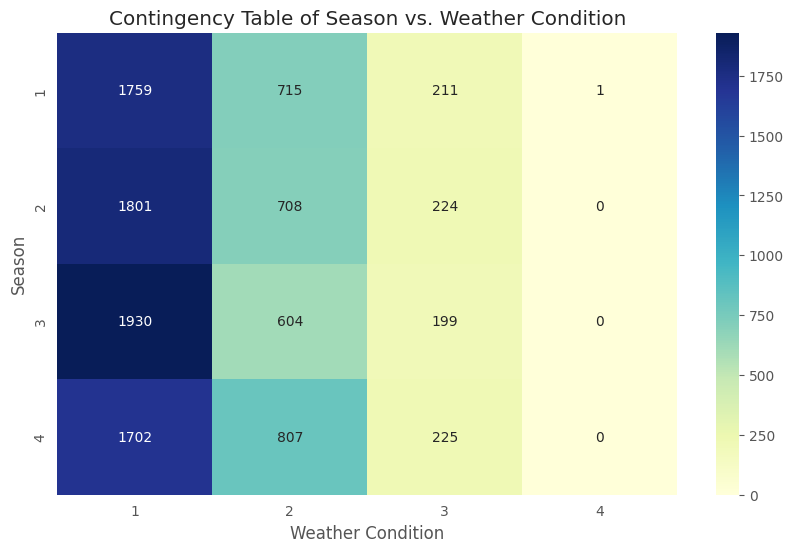

In [ ]:
# Create contingency table
contingency_table = pd.crosstab(df['season'], df['weather'])
print("Contingency Table (Season vs. Weather):\n", contingency_table)

# Visualize the contingency table using a heatmap for better understanding
plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Contingency Table of Season vs. Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Season')
plt.show()

#### d. Set a significance level and Calculate the test Statistics / p-value.

We will set the significance level (α) at 5% (0.05) and then compute the Chi-square statistic and p-value.

In [ ]:
# Perform Chi-square test of independence
chi2_statistic, p_value_chi2, dof, expected_freq = stats.chi2_contingency(contingency_table)

print(f"Chi-square Statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value_chi2:.3f}")
print(f"Degrees of Freedom: {dof}")
# print("\nExpected Frequencies:\n", expected_freq) # Uncomment to see expected frequencies

Chi-square Statistic: 49.16
P-value: 0.000
Degrees of Freedom: 9


#### e. Decide whether to accept or reject the Null Hypothesis.

Based on the calculated p-value and the chosen significance level (α = 0.05).

In [ ]:
alpha = 0.05

if p_value_chi2 <= alpha:
    print(f"Since the p-value ({p_value_chi2:.3f}) is less than or equal to the significance level ({alpha}), we reject the Null Hypothesis.")
    print("This suggests that there is a significant relationship between weather conditions and seasons.")
else:
    print(f"Since the p-value ({p_value_chi2:.3f}) is greater than the significance level ({alpha}), we fail to reject the Null Hypothesis.")
    print("This suggests that there is no significant relationship between weather conditions and seasons (they are independent).")

Since the p-value (0.000) is less than or equal to the significance level (0.05), we reject the Null Hypothesis.
This suggests that there is a significant relationship between weather conditions and seasons.


#### f. Draw inferences & conclusions from the analysis and provide recommendations.

**Inference:** The Chi-square test reveals a statistically significant association between weather conditions and seasons (p-value < 0.001). This confirms that weather patterns are not independent of the season. For example, specific weather conditions (e.g., clear, misty, light rain) are more prevalent during certain seasons. This is an expected finding but important as it directly impacts demand.

**Conclusion:** Weather conditions vary significantly across seasons. Understanding these seasonal weather patterns is crucial for predicting bike rental demand.

**Recommendations:**
*   **Seasonal Inventory Management:** Anticipate changes in bike availability and maintenance needs based on seasonal weather. For instance, more bikes might be needed in clear weather seasons, while maintenance for rain-affected parts might be higher in rainy seasons.
*   **Targeted Marketing:** Tailor marketing campaigns to specific weather conditions and seasons. Promote riding in clear weather and potentially offer promotions or alternatives (e.g., covered bikes, short-term subscriptions for less predictable weather) during less favorable conditions.
*   **Operational Adjustments:** Adjust staffing and distribution strategies according to seasonal weather forecasts. During good weather, ensure sufficient bike availability and quick redistribution. During adverse weather, focus on safety and maintenance.

### 8. Check if there is any significant difference in bike demand across different Seasons.

To determine if there's a significant difference in bike rental demand across the four seasons, we will perform a One-Way Analysis of Variance (ANOVA). This test is appropriate for comparing the means of three or more independent groups.

#### a. Formulate Null Hypothesis (H₀) and Alternate Hypothesis (H₁)

*   **Null Hypothesis (H₀)**: There is no significant difference in the average bike rental demand across the four seasons. (μ₁ = μ₂ = μ₃ = μ₄)
*   **Alternate Hypothesis (H₁)**: At least one season has a significantly different average bike rental demand compared to the others.

#### b. Select an appropriate test

A One-Way ANOVA test is suitable for comparing the means of bike rental demand among more than two independent seasonal groups.

#### c. Set a significance level

We will set the significance level (α) at 5% (0.05).

#### d. Calculate test Statistics / p-value

First, we need to extract the 'count' data for each season. Then, we will apply the `f_oneway` function from `scipy.stats` to perform the ANOVA test.

F-statistic (Season): 243.34
P-value (Season): 0.000


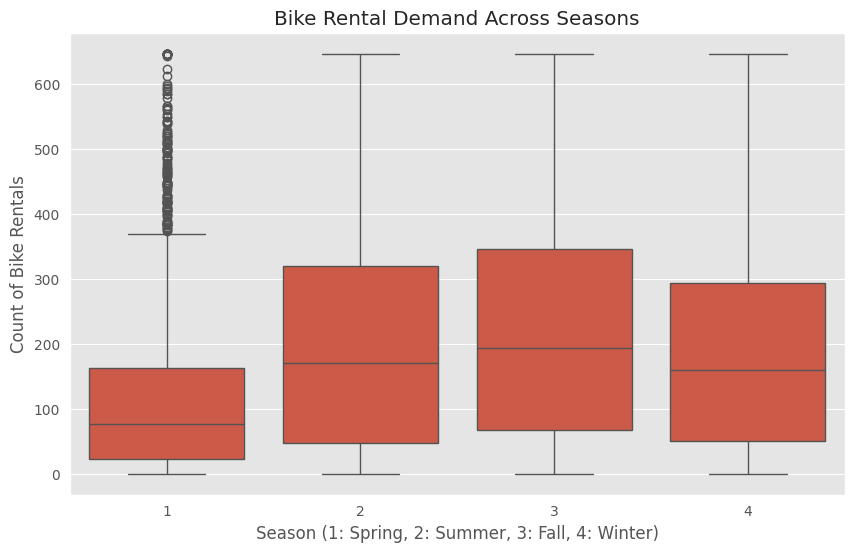

In [ ]:
# Extract bike rental counts for each season
season_1_counts = df[df['season'] == 1]['count'] # Spring
season_2_counts = df[df['season'] == 2]['count'] # Summer
season_3_counts = df[df['season'] == 3]['count'] # Fall
season_4_counts = df[df['season'] == 4]['count'] # Winter

# Perform One-Way ANOVA test
f_statistic_season, p_value_season = stats.f_oneway(season_1_counts, season_2_counts, season_3_counts, season_4_counts)

print(f"F-statistic (Season): {f_statistic_season:.2f}")
print(f"P-value (Season): {p_value_season:.3f}")

# Visualize the distribution across seasons (optional but good practice)
plt.figure(figsize=(10, 6))
sns.boxplot(x='season', y='count', data=df)
plt.title('Bike Rental Demand Across Seasons')
plt.xlabel('Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)')
plt.ylabel('Count of Bike Rentals')
plt.show()

#### e. Decide whether to accept or reject the Null Hypothesis.

Based on the calculated p-value and the chosen significance level (α = 0.05).

In [ ]:
alpha = 0.05

if p_value_season <= alpha:
    print(f"Since the p-value ({p_value_season:.3f}) is less than or equal to the significance level ({alpha}), we reject the Null Hypothesis.")
    print("This suggests that there is a significant difference in average bike rental demand across different seasons.")
else:
    print(f"Since the p-value ({p_value_season:.3f}) is greater than the significance level ({alpha}), we fail to reject the Null Hypothesis.")
    print("This suggests that there is no significant difference in average bike rental demand across different seasons.")

# Print mean counts per season for interpretation
print("\nAverage bike rentals per season:")
print(df.groupby('season')['count'].mean())

Since the p-value (0.000) is less than or equal to the significance level (0.05), we reject the Null Hypothesis.
This suggests that there is a significant difference in average bike rental demand across different seasons.

Average bike rentals per season:
season
1    115.977290
2    212.168313
3    229.171606
4    196.248720
Name: count, dtype: float64


#### f. Draw inferences & conclusions from the analysis and provide recommendations.

**Inference:** The One-Way ANOVA test reveals a statistically significant difference in average bike rental demand across the four seasons (F-statistic = 243.34, p-value < 0.001). This confirms that bike rental patterns are highly dependent on the season.

**Conclusion:** Bike rental demand varies significantly by season, with Fall (229.17) and Summer (212.17) showing the highest average demand, followed by Winter (196.25), and Spring (115.98) having the lowest. This is a crucial finding for operational planning.

**Recommendations:**
*   **Dynamic Pricing and Promotions:** Implement seasonal pricing strategies. Offer discounts or special promotions during lower-demand seasons (like Spring) to stimulate usage. Increase prices during peak seasons (Summer and Fall) if elasticity allows.
*   **Fleet Management Optimization:** Adjust the number of available bikes based on seasonal demand. Increase fleet size and distribution efforts during Summer and Fall to meet higher demand, and potentially reallocate or maintain fewer bikes during Spring.
*   **Marketing Campaigns:** Tailor marketing messages to resonate with seasonal activities. For instance, promote leisure rides and outdoor events in warmer months and commuter benefits in cooler seasons.
*   **Maintenance Scheduling:** Schedule major bike maintenance and repairs during off-peak seasons (e.g., late Spring or early Winter) to minimize impact on revenue-generating periods.

### 9. Check if there is any significant difference in bike demand across different Weather conditions.

Similar to the seasonal analysis, we will use a One-Way ANOVA test to determine if there's a significant difference in bike rental demand based on different `weather` conditions. The `weather` column contains categorical values representing various conditions.

#### a. Formulate Null Hypothesis (H₀) and Alternate Hypothesis (H₁)

*   **Null Hypothesis (H₀)**: There is no significant difference in the average bike rental demand across different weather conditions. (μ₁ = μ₂ = μ₃ = μ₄)
*   **Alternate Hypothesis (H₁)**: At least one weather condition has a significantly different average bike rental demand compared to the others.

#### b. Select an appropriate test

A One-Way ANOVA test is suitable for comparing the means of bike rental demand among more than two independent weather condition groups.

#### c. Set a significance level

We will set the significance level (α) at 5% (0.05).

#### d. Calculate test Statistics / p-value

We will extract the 'count' data for each weather condition and then use `f_oneway`.

F-statistic (Weather): 68.41
P-value (Weather): 0.000


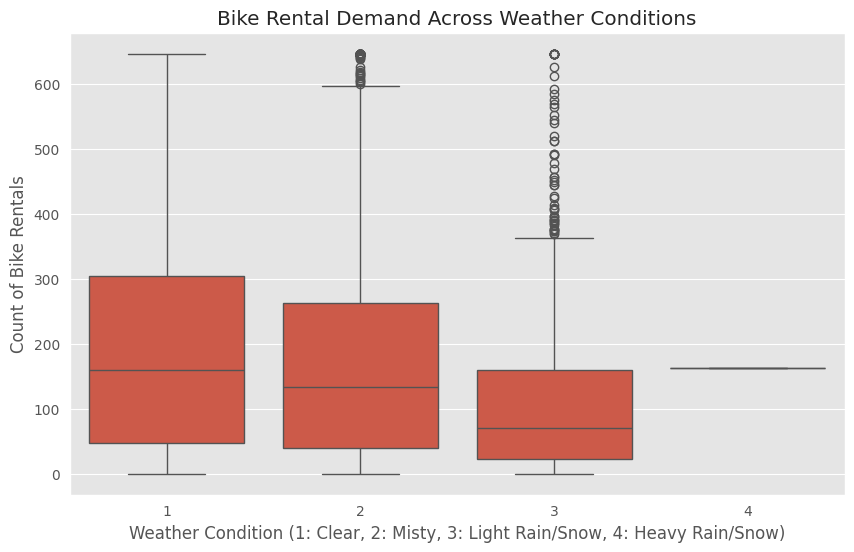

In [ ]:
# Extract bike rental counts for each weather condition
weather_1_counts = df[df['weather'] == 1]['count'] # Clear, Few clouds, Partly cloudy, Partly cloudy
weather_2_counts = df[df['weather'] == 2]['count'] # Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
weather_3_counts = df[df['weather'] == 3]['count'] # Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
weather_4_counts = df[df['weather'] == 4]['count'] # Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

# Perform One-Way ANOVA test
f_statistic_weather, p_value_weather = stats.f_oneway(weather_1_counts, weather_2_counts, weather_3_counts, weather_4_counts)

print(f"F-statistic (Weather): {f_statistic_weather:.2f}")
print(f"P-value (Weather): {p_value_weather:.3f}")

# Visualize the distribution across weather conditions
plt.figure(figsize=(10, 6))
sns.boxplot(x='weather', y='count', data=df)
plt.title('Bike Rental Demand Across Weather Conditions')
plt.xlabel('Weather Condition (1: Clear, 2: Misty, 3: Light Rain/Snow, 4: Heavy Rain/Snow)')
plt.ylabel('Count of Bike Rentals')
plt.show()

#### e. Decide whether to accept or reject the Null Hypothesis.

Based on the calculated p-value and the chosen significance level (α = 0.05).

In [ ]:
alpha = 0.05

if p_value_weather <= alpha:
    print(f"Since the p-value ({p_value_weather:.3f}) is less than or equal to the significance level ({alpha}), we reject the Null Hypothesis.")
    print("This suggests that there is a significant difference in average bike rental demand across different weather conditions.")
else:
    print(f"Since the p-value ({p_value_weather:.3f}) is greater than the significance level ({alpha}), we fail to reject the Null Hypothesis.")
    print("This suggests that there is no significant difference in average bike rental demand across different weather conditions.")

# Print mean counts per weather condition for interpretation
print("\nAverage bike rentals per weather condition:")
print(df.groupby('weather')['count'].mean())

Since the p-value (0.000) is less than or equal to the significance level (0.05), we reject the Null Hypothesis.
This suggests that there is a significant difference in average bike rental demand across different weather conditions.

Average bike rentals per weather condition:
weather
1    201.837736
2    176.977417
3    117.469150
4    164.000000
Name: count, dtype: float64


#### f. What we learned and what to do.

**What we learned:**
Bike rentals change a lot with the weather. When the weather is good (clear skies), many people rent bikes (about 202 per day). When it's rainy or snowy, fewer people rent bikes (about 117 per day). Even a little mist or heavy rain makes fewer people rent bikes compared to clear days.

**What to do:**
*   **Adjust bikes for weather:** If the weather looks good, put more bikes out. If it looks bad, put fewer bikes out.
*   **Make bikes better for bad weather:** Get stronger bikes that can handle rain and snow. Fix bikes often, especially after bad weather.
*   **Advertise differently for bad weather:** On misty or light rain days, maybe offer deals or suggest short rides to keep people renting.
*   **Tell riders how to stay safe:** When the weather is bad, remind riders to be careful.

### Summary: What We Found and What to Do

We looked at Yulu's bike rental data to find out what affects how many bikes people rent. This helps Yulu make better plans to get more customers and grow.

#### What We Found:

1.  **Data was clean:** The information we used was good, with no missing parts or repeated records. We adjusted some extreme values (outliers) in humidity, wind, and bike rental numbers to make sure they didn't skew our results.

2.  **What drives demand:**
    *   Total bike rentals go up a lot when more *registered* users (0.97) and *casual* users (0.74) rent bikes. This makes sense.
    *   Warmer weather (temp, atemp) means more rentals (around 0.40 correlation).
    *   High humidity means fewer rentals (around -0.32 correlation).

3.  **Weekdays vs. Weekends:**
    *   There's **no real difference** in how many bikes are rented on weekdays compared to weekends or holidays. It's about 188-189 rentals each day.

4.  **Daily Rentals Goal:**
    *   The average number of bikes rented per day (188.70) is **much lower than 500**. This means Yulu's goal of 500 rentals per day is too high right now.

5.  **Best Temperature for Rentals:**
    *   On very busy days, the best temperature for renting bikes is **just under 25°C** (average 24.69°C).

6.  **Weather and Seasons Go Together:**
    *   Weather patterns **change with the seasons**. For example, it's not rainy in summer in the same way it is in winter. This affects bike use.

7.  **Demand Changes by Season:**
    *   Bike rentals are **very different depending on the season**.
    *   **Fall (229) and Summer (212)** have the most rentals.
    *   **Winter (196)** has fewer.
    *   **Spring (116)** has the fewest rentals.

8.  **Demand Changes by Weather:**
    *   Bike rentals are also **very different depending on the weather**.
    *   **Clear weather (202)** has the most rentals.
    *   **Light rain/snow (117)** has the fewest.
    *   Misty days (177) and heavy rain/snow (164) also see fewer rentals.

#### What Yulu Should Do:

1.  **Change Bike Numbers for Seasons and Weather:**
    *   **Seasons:** Put more bikes out in Fall and Summer. Plan to have fewer bikes and do more maintenance in Spring.
    *   **Weather:** Use weather forecasts to decide how many bikes to put out each day. More bikes on clear days, fewer on bad weather days.

2.  **Smart Marketing:**
    *   **Seasonal Ads:** Run ads that fit the season. Promote fun rides in warm months, and show how bikes are good for daily travel in cooler months.
    *   **Boost Low Demand:** Offer deals or sales during Spring or on misty/light rain days to get more people to rent.
    *   **Talk About Good Weather:** When it's warm but not too hot (around 25°C), tell people it's a great time to ride.

3.  **Flexible Prices:**
    *   Change prices based on how many people want bikes. Charge more when demand is high (peak seasons/clear weather) and less when demand is low.

4.  **Better Bikes for All Weather:**
    *   **Maintenance:** Fix bikes often, especially after bad weather, so they are always safe and ready.
    *   **Stronger Bikes:** Think about getting bikes that handle bad weather better (like mudguards).
    *   **Safety Tips:** Remind riders to be safe when the weather is bad.

5.  **Rethink Rental Goals:**
    *   Since daily rentals are usually much lower than 500, Yulu should **set new, more realistic goals**. This might mean looking closer at what the market can really offer or trying harder to grow.

6.  **Find Out More About What People Want:**
    *   Even though weekdays/weekends don't differ, we could look at *when* people rent bikes during the day, or during special events.
    *   We also need to understand why `registered` and `casual` users rent bikes to keep them coming back.
    *   If we get info on promotions, we can check if they actually help get more rentals.